In [1]:
# ============================================================
# 1) Import libraries
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import numpy as np
from scipy import io
import os

In [2]:
# ============================================================
# 2) Set random seed
# ============================================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

In [3]:
# ============================================================
# 3) VAE configuration
# ============================================================

VAE_CONFIG = {
    'latent_dim': 16,
    'batch_size': 128,
    'epochs': 50,
    'learning_rate': 0.001,
    'train_ratio': 0.8,
    'target_size': 28
}

In [4]:
# ============================================================
# 4) Load and preprocess HODA dataset
# ============================================================

def get_dataset(data_path='/content/Data_hoda_full.mat'):
    data = io.loadmat(data_path)
    images = np.squeeze(data['Data'])
    total_samples = images.shape[0]

    print(f"Total samples in dataset: {total_samples}")

    max_r = 0
    max_c = 0

    for img in images:
        r, c = img.shape

        if r > max_r:
            max_r = r

        if c > max_c:
            max_c = c

    print(f"Max image height: {max_r}")
    print(f"Max image width: {max_c}")

    max_dim = max(max_r, max_c)
    canvas_h, canvas_w = max_dim, max_dim

    processed = np.zeros((total_samples, canvas_h, canvas_w), dtype=np.float32)

    for i, img in enumerate(images):
        r, c = img.shape

        canvas = np.zeros((canvas_h, canvas_w), dtype=np.float32)

        r_start = (canvas_h - r) // 2
        c_start = (canvas_w - c) // 2

        canvas[r_start:r_start + r, c_start:c_start + c] = img.astype(np.float32)

        processed[i] = canvas / 255.0

    target_size = VAE_CONFIG['target_size']

    processed = processed[..., np.newaxis]

    processed = tf.image.resize(
        processed,
        [target_size, target_size],
        method='area'
    ).numpy()

    processed = np.clip(processed, 0.0, 1.0)

    processed = processed[..., 0].astype(np.float32)

    VAE_CONFIG['image_height'] = target_size
    VAE_CONFIG['image_width'] = target_size

    train_count = int(total_samples * VAE_CONFIG['train_ratio'])

    train_data = processed[:train_count]
    test_data = processed[train_count:]

    rng = np.random.default_rng(RANDOM_SEED)
    train_indices = rng.permutation(train_data.shape[0])
    train_data = train_data[train_indices]

    print(f"Train samples: {train_data.shape[0]}")
    print(f"Test samples: {test_data.shape[0]}")
    print(f"Image shape: ({target_size}, {target_size})")

    return train_data, test_data

train_data, test_data = get_dataset()

Total samples in dataset: 60000
Max image height: 62
Max image width: 51
Train samples: 48000
Test samples: 12000
Image shape: (28, 28)


In [5]:
# ============================================================
# 5) Sampling layer
# ============================================================

@tf.keras.utils.register_keras_serializable(package="Custom")
class Sampling(layers.Layer):

    def call(self, inputs):
        z_mean, z_log_var = inputs

        z_log_var_clipped = tf.clip_by_value(z_log_var, -10.0, 2.0)

        batch_size = tf.shape(z_mean)[0]
        latent_dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch_size, latent_dim))

        return z_mean + tf.exp(0.5 * z_log_var_clipped) * epsilon

    def get_config(self):
        config = super().get_config()
        return config

In [6]:
# ============================================================
# 6) Build Encoder
# ============================================================

def build_encoder(input_shape, latent_dim):
    inputs = layers.Input(shape=input_shape)

    x = layers.Flatten()(inputs)

    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)

    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

    z = Sampling(name='z')([z_mean, z_log_var])

    return Model(inputs, [z_mean, z_log_var, z], name='Encoder')

In [7]:
# ============================================================
# 7) Build Decoder
# ============================================================

def build_decoder(latent_dim, output_shape):
    inputs = layers.Input(shape=(latent_dim,))

    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(512, activation='relu')(x)

    x = layers.Dense(
        output_shape[0] * output_shape[1],
        activation='sigmoid'
    )(x)

    outputs = layers.Reshape(output_shape)(x)

    return Model(inputs, outputs, name='Decoder')

In [8]:
# ============================================================
# 8) Create Encoder and Decoder
# ============================================================

image_shape = (
    VAE_CONFIG['image_height'],
    VAE_CONFIG['image_width']
)

encoder = build_encoder(
    image_shape,
    VAE_CONFIG['latent_dim']
)

decoder = build_decoder(
    VAE_CONFIG['latent_dim'],
    image_shape
)

encoder.summary()
decoder.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 784)       │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    401,920 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │      2,064 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      2,064 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 16)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 570,272 (2.18 MB)

 Trainable params: 570,272 (2.18 MB)

 Non-trainable params: 0 (0.00 B)

Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 784)            │       402,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 568,976 (2.17 MB)

 Trainable params: 568,976 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ============================================================
# 9) Define custom VAE model
# ============================================================

class VAE(Model):

    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.image_pixels = (
            VAE_CONFIG['image_height'] * VAE_CONFIG['image_width']
        )

        self.total_loss_tracker = tf.keras.metrics.Mean(name='loss')
        self.recon_loss_tracker = tf.keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker = tf.keras.metrics.Mean(name='kl_loss')
        self.pixel_acc_tracker = tf.keras.metrics.Mean(name='pixel_accuracy')

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.recon_loss_tracker,
            self.kl_loss_tracker,
            self.pixel_acc_tracker
        ]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def compute_losses(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        data_flat = tf.reshape(data, [-1, self.image_pixels])
        recon_flat = tf.reshape(reconstruction, [-1, self.image_pixels])

        recon_loss = tf.reduce_mean(
            tf.reduce_sum(
                -(
                    data_flat * tf.math.log(recon_flat + 1e-7) +
                    (1.0 - data_flat) * tf.math.log(1.0 - recon_flat + 1e-7)
                ),
                axis=-1
            )
        )

        z_log_var_clipped = tf.clip_by_value(z_log_var, -10.0, 2.0)

        kl_loss = tf.reduce_mean(
            -0.5 * tf.reduce_sum(
                1.0 +
                z_log_var_clipped -
                tf.square(z_mean) -
                tf.exp(z_log_var_clipped),
                axis=-1
            )
        )

        total_loss = recon_loss + kl_loss

        true_bin = tf.cast(data_flat >= 0.5, tf.float32)
        pred_bin = tf.cast(recon_flat >= 0.5, tf.float32)

        pixel_acc = tf.reduce_mean(
            tf.cast(tf.equal(true_bin, pred_bin), tf.float32)
        )

        return total_loss, recon_loss, kl_loss, pixel_acc

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss, pixel_acc = self.compute_losses(data)

        grads = tape.gradient(total_loss, self.trainable_weights)

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.pixel_acc_tracker.update_state(pixel_acc)

        return {
            m.name: m.result()
            for m in self.metrics
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        total_loss, recon_loss, kl_loss, pixel_acc = self.compute_losses(data)

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.pixel_acc_tracker.update_state(pixel_acc)

        return {
            m.name: m.result()
            for m in self.metrics
        }

In [10]:
# ============================================================
# 10) Compile VAE
# ============================================================

vae = VAE(encoder, decoder)

vae.compile(
    optimizer=tf.keras.optimizers.Adam(
        VAE_CONFIG['learning_rate']
    )
)

In [11]:
# ============================================================
# 11) Train VAE
# ============================================================

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = vae.fit(
    train_data,
    batch_size=VAE_CONFIG['batch_size'],
    epochs=VAE_CONFIG['epochs'],
    validation_data=(test_data, test_data),
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - kl_loss: 3.4574 - loss: 92.4045 - pixel_accuracy: 0.9501 - recon_loss: 88.9471 - val_kl_loss: 5.8982 - val_loss: 69.3677 - val_pixel_accuracy: 0.9636 - val_recon_loss: 63.4695
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - kl_loss: 6.8040 - loss: 64.0045 - pixel_accuracy: 0.9687 - recon_loss: 57.2005 - val_kl_loss: 7.5605 - val_loss: 59.8712 - val_pixel_accuracy: 0.9726 - val_recon_loss: 52.3107
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - kl_loss: 7.8345 - loss: 58.1957 - pixel_accuracy: 0.9741 - recon_loss: 50.3612 - val_kl_loss: 8.0014 - val_loss: 56.9899 - val_pixel_accuracy: 0.9753 - val_recon_loss: 48.9885
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - kl_loss: 8.1398 - loss: 56.2246 - pixel_accuracy: 0.9759 - recon_loss: 48.0848 - val_kl_loss: 8.2944 - val_loss: 55.7037 - val_pixel_accuracy: 0.9765 - val_recon_loss: 47.4092
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - kl_loss: 8.4282 

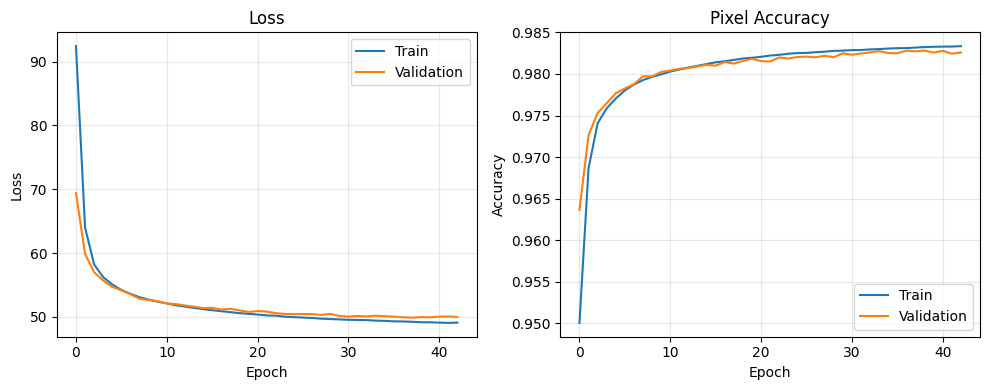

In [12]:
# ============================================================
# 12) Plot training curves
# ============================================================

_, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history.history['loss'], label='Train')

if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='Validation')

axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

if 'pixel_accuracy' in history.history:
    axes[1].plot(history.history['pixel_accuracy'], label='Train')

if 'val_pixel_accuracy' in history.history:
    axes[1].plot(history.history['val_pixel_accuracy'], label='Validation')

axes[1].set_title('Pixel Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

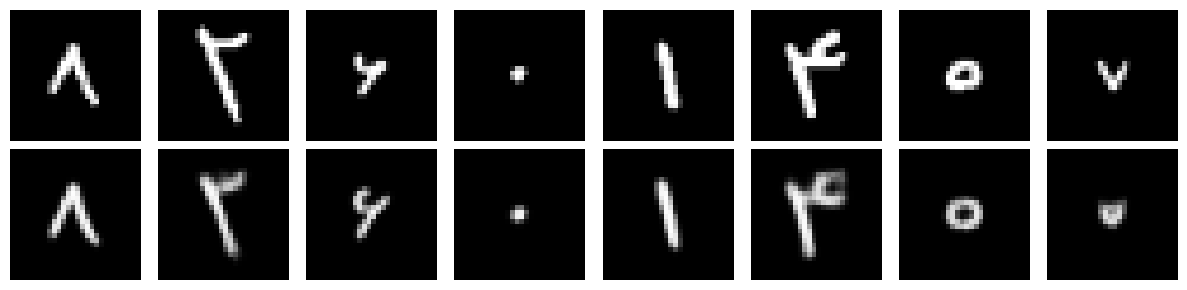

In [13]:
# ============================================================
# 13) Reconstruct test images
# ============================================================

reconstructed = vae.predict(
    test_data[:8],
    verbose=0
)

_, axes = plt.subplots(2, 8, figsize=(12, 3))

for i in range(8):
    axes[0, i].imshow(
        test_data[i],
        cmap='gray',
        interpolation='nearest',
        vmin=0,
        vmax=1
    )
    axes[0, i].axis('off')

    axes[1, i].imshow(
        reconstructed[i],
        cmap='gray',
        interpolation='nearest',
        vmin=0,
        vmax=1
    )
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Recon')

plt.tight_layout()
plt.show()

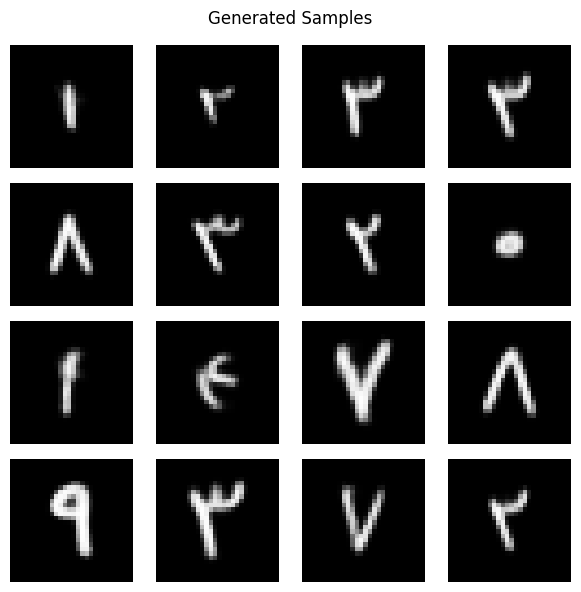

In [14]:
# ============================================================
# 14) Generate new samples
# ============================================================

z_sample = tf.random.normal(
    (16, VAE_CONFIG['latent_dim'])
)

generated = decoder.predict(
    z_sample,
    verbose=0
)

_, axes = plt.subplots(4, 4, figsize=(6, 6))

for i in range(16):
    axes[i // 4, i % 4].imshow(
        generated[i],
        cmap='gray',
        interpolation='nearest',
        vmin=0,
        vmax=1
    )
    axes[i // 4, i % 4].axis('off')

plt.suptitle('Generated Samples')
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 15) Save encoder and decoder
# ============================================================

save_dir = '/content/vae_models'
os.makedirs(save_dir, exist_ok=True)

encoder.save(
    os.path.join(save_dir, 'encoder.keras')
)

decoder.save(
    os.path.join(save_dir, 'decoder.keras')
)

print("Encoder saved to:", os.path.join(save_dir, 'encoder.keras'))
print("Decoder saved to:", os.path.join(save_dir, 'decoder.keras'))

Encoder saved to: /content/vae_models/encoder.keras
Decoder saved to: /content/vae_models/decoder.keras


In [16]:
# ============================================================
# 16) Test loading saved models
# ============================================================

loaded_encoder = tf.keras.models.load_model(
    os.path.join(save_dir, 'encoder.keras')
)

loaded_decoder = tf.keras.models.load_model(
    os.path.join(save_dir, 'decoder.keras')
)

print("Encoder and decoder loaded successfully.")

Encoder and decoder loaded successfully.


In [17]:
# ============================================================
# 17) Download saved models from Colab
# ============================================================

from google.colab import files

files.download(
    os.path.join(save_dir, 'encoder.keras')
)

files.download(
    os.path.join(save_dir, 'decoder.keras')
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>